# 06 — Two-phase fine-tuning of YOLOv8n on warehouse-delivery-box

**Goal.** Adapt YOLOv8n (pretrained on COCO) to warehouse imagery via
the classical 2-phase transfer-learning recipe (Howard & Ruder 2018,
ULMFiT). Compare against the no-freeze baseline trained by notebook
`00_colab_training.ipynb`.

## Why two phases (and not just one long training run)

| Phase | What's trainable | Why |
|---|---|---|
| **1** (`freeze=10`, 10 epochs, lr=1e-3) | detection head only | The Kaggle warehouse dataset is small (361 train images). With the backbone frozen, COCO's general features (edges, textures, blob detection) are protected from being overwritten before the head has converged to the warehouse class structure. |
| **2** (`freeze=7`, 30 epochs, lr=1e-4) | head + last 3 backbone blocks | Once the head is reasonable, the deepest backbone layers adapt to warehouse-specific features (overhead view, low light, cardboard occlusions). Earlier layers stay frozen — they encode universal visual primitives that we don't want to disrupt. |

This is the standard ULMFiT recipe applied to detection. The
no-freeze baseline (notebook 00) trains everything from epoch 1 at
the same LR — easier to overfit on a 361-image dataset.

## What this notebook produces

| Artefact | Path |
|---|---|
| Phase-1 model | `runs/two_phase/phase1/weights/best.pt` |
| Phase-2 model | `runs/two_phase/phase2/weights/best.pt` |
| Comparison table | inline + `metrics.json` |
| Downloadable bundle | `logivision_two_phase_<timestamp>.zip` |

After Colab finishes, drop `phase2/weights/best.pt` into
`ml/runs/two_phase/weights/` locally, then:
```
make register-from-colab RUN=two_phase
make worker-restart
```


In [1]:
# 1. Verify we are on a GPU runtime. T4 takes ~30 min for both phases combined.
import sys
print('Python:', sys.version.split()[0])
try:
    import torch
    print('PyTorch:', torch.__version__)
    if not torch.cuda.is_available():
        print('\n  WARNING: no GPU detected — switch runtime: Runtime → Change runtime type → T4 GPU')
    else:
        print('GPU :', torch.cuda.get_device_name(0))
        print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
except ImportError:
    print('  Torch not installed yet — cell 2 will fix that.')


Python: 3.12.13
PyTorch: 2.12.0+cu130
GPU : Tesla T4
VRAM: 15.6 GB


In [2]:
# 2. Clone the LOGIVISION repo, set sys.path, install training deps.
import pathlib, os, sys
REPO_URL  = 'https://github.com/Ayalem/logivision_v2'
REPO_DIR  = pathlib.Path('/content/logivision_v2')
if not REPO_DIR.is_dir():
    !git clone --depth 1 {REPO_URL} {REPO_DIR}
os.chdir(REPO_DIR)
print('cwd:', os.getcwd())

# Add the repo root + scripts/ to sys.path so `import services.*` and
# `import prepare_kaggle_warehouse` resolve to the cloned files. Without
# this Python only searches site-packages — `pip install services` would
# pull an unrelated PyPI package, NOT our local module. Do not do that.
for p in (str(REPO_DIR), str(REPO_DIR / 'scripts')):
    if p not in sys.path:
        sys.path.insert(0, p)
print('sys.path[0:3] =', sys.path[:3])

# Sanity: confirm the services pkg cloned correctly.
assert (REPO_DIR / 'services' / 'model_server' / 'service.py').is_file(), (
    'services/model_server/service.py missing — clone is stale; re-run git clone'
)

%pip install -q ultralytics==8.3.0 kagglehub==0.3.0 pyyaml==6.0.1
print('deps installed')


cwd: /content/logivision_v2
sys.path[0:3] = ['/content/logivision_v2/scripts', '/content/logivision_v2', '/content']
deps installed


In [3]:
# 3. Pull Kaggle credentials from Colab Secrets and write ~/.kaggle/kaggle.json.
import json, os, pathlib
try:
    from google.colab import userdata
    KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
    KAGGLE_KEY      = userdata.get('KAGGLE_KEY')
    assert KAGGLE_USERNAME and KAGGLE_KEY, 'Missing Colab secret'
except (ImportError, Exception) as e:
    KAGGLE_USERNAME = os.environ.get('KAGGLE_USERNAME')
    KAGGLE_KEY      = os.environ.get('KAGGLE_KEY')
    assert KAGGLE_USERNAME and KAGGLE_KEY, (
        f'No Kaggle creds ({e}). Add KAGGLE_USERNAME and KAGGLE_KEY as Colab Secrets.'
    )

kj = pathlib.Path.home() / '.kaggle' / 'kaggle.json'
kj.parent.mkdir(exist_ok=True)
kj.write_text(json.dumps({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}))
os.chmod(kj, 0o600)
print('kaggle.json written; username =', KAGGLE_USERNAME)


kaggle.json written; username = ayalemzouri



In [4]:
# 4. Download dataset (~860 MB cached) and convert OBB labels -> AABB.
import kagglehub, pathlib, sys
DATASET_PATH = kagglehub.dataset_download('zoya77/warehouse-delivery-box-detection-dataset')
KAGGLE_BOX = pathlib.Path(DATASET_PATH) / 'Box Dataset'
assert KAGGLE_BOX.is_dir(), f'Unexpected layout: {list(pathlib.Path(DATASET_PATH).iterdir())}'

sys.path.insert(0, 'scripts')
import prepare_kaggle_warehouse as prep
prep.ROOT = KAGGLE_BOX
prep.OUT  = pathlib.Path('data/processed/kaggle_warehouse')
prep.main()

DATA_YAML = (prep.OUT / 'data.yaml').resolve()
print('data.yaml:', DATA_YAML)


  train:   361 images ·   361 labels ·   9960 AABB instances
  val  :    99 images ·    99 labels ·   2712 AABB instances
  test :    61 images ·    61 labels ·   1772 AABB instances

✓ wrote data/processed/kaggle_warehouse/data.yaml
  classes: ['box_small', 'box_medium', 'box_large']
  splits : {'train': 361, 'val': 99, 'test': 61}
data.yaml: /content/logivision_v2/data/processed/kaggle_warehouse/data.yaml


In [7]:
%pip install -q -U ultralytics

In [9]:
import numpy as np
import pandas as pd
import scipy
import ultralytics # Added import statement

print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("scipy :", scipy.__version__)
print("numpy:", np.__version__)
print("ultralytics:", ultralytics.__version__)

numpy : 1.26.4
pandas: 2.2.2
scipy : 1.17.1
numpy: 1.26.4
ultralytics: 8.4.60


In [10]:
# 5. PHASE 1 — backbone FROZEN, train detection head only.
#    Ultralytics freezes layers 0..N-1 when you pass freeze=N.
#    YOLOv8n architecture:
#       backbone = layers 0..9   (10 layers)
#       head     = layers 10..22
#    So freeze=10 = backbone frozen, head trainable.
from ultralytics import YOLO
import time, pathlib

PHASE1_DIR = pathlib.Path('runs/two_phase')
PHASE1_DIR.mkdir(parents=True, exist_ok=True)

print('=' * 60)
print('PHASE 1 — backbone frozen, head only, 10 epochs, lr=1e-3')
print('=' * 60)
t0 = time.perf_counter()

model = YOLO('yolov8n.pt')   # COCO-pretrained weights
phase1_results = model.train(
    data=str(DATA_YAML),
    epochs=10,
    imgsz=640,
    batch=32,
    optimizer='AdamW',
    lr0=1e-3,
    freeze=10,                # freeze backbone (layers 0..9)
    cos_lr=True,
    patience=5,
    device=0,
    project='runs/two_phase',
    name='phase1',
    exist_ok=True,
    verbose=False,
    plots=True,
    seed=42,
)
print(f'\nphase 1 wall-clock: {(time.perf_counter() - t0):.0f}s')
import numpy as np
import ultralytics

print("numpy:", np.__version__)
print("ultralytics:", ultralytics.__version__)


PHASE 1 — backbone frozen, head only, 10 epochs, lr=1e-3
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/logivision_v2/data/processed/kaggle_warehouse/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=phase1, nbs=64, 

In [11]:
# 6. Evaluate Phase 1 on the held-out test split.
phase1_val = model.val(data=str(DATA_YAML), split='test', verbose=False)
phase1_metrics = {
    'mAP50':       float(phase1_val.box.map50),
    'mAP50-95':    float(phase1_val.box.map),
    'precision':   float(phase1_val.box.mp),
    'recall':      float(phase1_val.box.mr),
}
print('PHASE 1 — held-out TEST split metrics:')
for k, v in phase1_metrics.items():
    print(f'  {k:<10s} = {v:.4f}')


Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 177.6±20.5 MB/s, size: 1178.6 KB)
val: Scanning /content/logivision_v2/data/processed/kaggle_warehouse/labels/test... 61 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 61/61 559.7it/s 0.1s
val: New cache created: /content/logivision_v2/data/processed/kaggle_warehouse/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.2s/it 8.9s
                   all         61       1772      0.466      0.452      0.436      0.302
Speed: 5.3ms preprocess, 12.8ms inference, 0.0ms loss, 10.5ms postprocess per image
Results saved to /content/logivision_v2/runs/detect/val
PHASE 1 — held-out TEST split metrics:
  mAP50      = 0.4358
  mAP50-95   = 0.3015
  precision  = 0.4657
  recall     = 0.4515


In [13]:
# 7. PHASE 2 — Unfreeze last 3 backbone blocks (layers 7..9), keep
#    layers 0..6 frozen. Lower LR (1e-4) so the unfrozen blocks adapt
#    gently without disrupting the head we just trained.
#    Start from the Phase-1 weights (best.pt).
import pathlib
import time # Added import for time module

# Corrected path to include 'runs/detect/' as ultralytics saves results there.
phase1_best = pathlib.Path('runs/detect/runs/two_phase/phase1/weights/best.pt')
assert phase1_best.is_file(), f'Phase 1 weights not found at {phase1_best}'

print('=' * 60)
print('PHASE 2 — last 3 backbone blocks unfrozen, 30 epochs, lr=1e-4')
print('=' * 60)
t0 = time.perf_counter()

model2 = YOLO(str(phase1_best))  # start from Phase-1 best
phase2_results = model2.train(
    data=str(DATA_YAML),
    epochs=30,
    imgsz=640,
    batch=32,
    optimizer='AdamW',
    lr0=1e-4,                  # 10x lower — gentle fine-tuning
    freeze=7,                  # freeze layers 0..6, unfreeze 7..9
    cos_lr=True,
    patience=10,
    device=0,
    project='runs/two_phase',
    name='phase2',
    exist_ok=True,
    verbose=False,
    plots=True,
    seed=42,
)
print(f'\nphase 2 wall-clock: {(time.perf_counter() - t0):.0f}s')


PHASE 2 — last 3 backbone blocks unfrozen, 30 epochs, lr=1e-4
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/logivision_v2/data/processed/kaggle_warehouse/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=7, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/runs/two_phase/phase1/weights/best.pt, momentum=0.937, mosaic

In [14]:
# 8. Evaluate Phase 2 on the held-out test split + side-by-side comparison.
phase2_val = model2.val(data=str(DATA_YAML), split='test', verbose=False)
phase2_metrics = {
    'mAP50':       float(phase2_val.box.map50),
    'mAP50-95':    float(phase2_val.box.map),
    'precision':   float(phase2_val.box.mp),
    'recall':      float(phase2_val.box.mr),
}
print('PHASE 2 — held-out TEST split metrics:')
for k, v in phase2_metrics.items():
    print(f'  {k:<10s} = {v:.4f}')

print()
print(f'{"Metric":<12s} {"Phase 1":<10s} {"Phase 2":<10s} {"Delta":<10s}')
print('-' * 44)
for k in phase1_metrics:
    p1, p2 = phase1_metrics[k], phase2_metrics[k]
    delta = p2 - p1
    arrow = '↑' if delta > 0 else ('↓' if delta < 0 else '=')
    print(f'{k:<12s} {p1:<10.4f} {p2:<10.4f} {delta:+.4f} {arrow}')


Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2802.9±456.0 MB/s, size: 2254.2 KB)
val: Scanning /content/logivision_v2/data/processed/kaggle_warehouse/labels/test.cache... 61 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 61/61 11.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.1s/it 8.4s
                   all         61       1772        0.6      0.599      0.606      0.424
Speed: 6.4ms preprocess, 5.0ms inference, 0.0ms loss, 8.5ms postprocess per image
Results saved to /content/logivision_v2/runs/detect/val-2
PHASE 2 — held-out TEST split metrics:
  mAP50      = 0.6059
  mAP50-95   = 0.4240
  precision  = 0.5996
  recall     = 0.5989

Metric       Phase 1    Phase 2    Delta     
--------------------------------------------
mAP50       

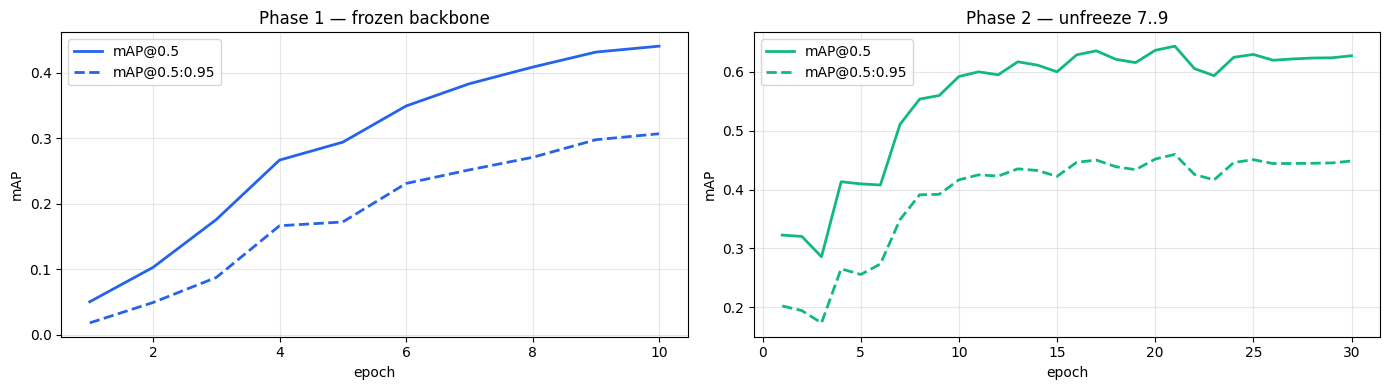

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import pathlib # Ensure pathlib is imported

def _load_results(phase_dir):
    # Ultralytics saves results under runs/detect/runs/two_phase/
    base_results_path = pathlib.Path('runs/detect/runs/two_phase')
    candidates = list(base_results_path.glob(f'**/{phase_dir}/results.csv'))
    if not candidates:
        # Fallback to direct path if glob doesn't find it (less likely with correct base_results_path)
        candidates = [base_results_path / phase_dir / 'results.csv']
    return pd.read_csv(candidates[0]).rename(columns=lambda c: c.strip())

p1_df = _load_results('phase1')
p2_df = _load_results('phase2')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, df, title, col in [
    (axes[0], p1_df, 'Phase 1 — frozen backbone', '#2563EB'),
    (axes[1], p2_df, 'Phase 2 — unfreeze 7..9', '#10B981'),
]:
    ax.plot(df['epoch'], df['metrics/mAP50(B)'],     label='mAP@0.5',     color=col,        linewidth=2)
    ax.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95', color=col,        linewidth=2, linestyle='--')
    ax.set_xlabel('epoch'); ax.set_ylabel('mAP'); ax.set_title(title)
    ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

In [17]:
# 10. Persist metrics + zip the Phase-2 best.pt for download.
import json, shutil
from datetime import datetime, timezone

OUT = pathlib.Path('runs/two_phase')
metrics_blob = {
    'phase1': phase1_metrics,
    'phase2': phase2_metrics,
    'delta': {k: phase2_metrics[k] - phase1_metrics[k] for k in phase1_metrics},
    'config': {
        'dataset': 'zoya77/warehouse-delivery-box-detection-dataset',
        'arch': 'yolov8n.pt',
        'phase1': {'freeze': 10, 'epochs': 10, 'lr0': 1e-3},
        'phase2': {'freeze': 7, 'epochs': 30, 'lr0': 1e-4},
    },
}
(OUT / 'metrics.json').write_text(json.dumps(metrics_blob, indent=2))
print('metrics.json written')

stamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')
bundle_root = pathlib.Path(f'bundle_two_phase_{stamp}')
bundle_root.mkdir(exist_ok=True)
phase2_best = OUT / 'phase2' / 'weights' / 'best.pt'
if phase2_best.is_file():
    (bundle_root / 'weights').mkdir(exist_ok=True)
    shutil.copy(phase2_best, bundle_root / 'weights' / 'best.pt')
shutil.copy(OUT / 'metrics.json', bundle_root / 'metrics.json')
# Copy training curves CSVs too.
for p in ('phase1', 'phase2'):
    src = OUT / p / 'results.csv'
    if src.is_file():
        shutil.copy(src, bundle_root / f'results_{p}.csv')

zip_path = shutil.make_archive(str(bundle_root), 'zip', bundle_root)
print(f'bundle: {zip_path} ({pathlib.Path(zip_path).stat().st_size // 1024} KB)')

try:
    from google.colab import files
    files.download(zip_path)
    print('download triggered')
except ImportError:
    print('(outside Colab — bundle saved to disk)')


metrics.json written
bundle: /content/logivision_v2/bundle_two_phase_20260606T202215Z.zip (0 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

download triggered


## Next steps after Colab finishes

1. Unzip the downloaded bundle into the repo at `ml/runs/two_phase/`:
   ```
   unzip ~/Downloads/bundle_two_phase_*.zip -d ml/runs/two_phase/
   ```
2. Register the new model as the Production version in MLflow:
   ```
   make register-from-colab RUN=two_phase
   ```
3. Restart the inference worker so it picks up the new weights:
   ```
   make worker-restart
   ```
4. The dashboard's AI Model Status panel will show the new model version
   on next refresh.
